## RunModels_ForEachOfNClusters
This script:
- Reads the expanded dataframe (one row per image) with cluster assignments (output of script 5)
- For a chosen k, computes per-LSOA summary statistics:
    - Count and percentage of images in each cluster
    - Mean, max, and median embedding within each cluster
    - Overall mean, max, and median embedding (across all clusters)
- Joins to IMD ranking data
- For each of the N clusters, trains an XGBoost model using only that cluster's embedding as features, with a simple 80/20 train-test split
- Compares model performance (R², RMSE, Spearman correlation) across clusters

In [14]:
import os
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from sklearn.base import clone
import matplotlib.pyplot as plt
import joblib

In [15]:
from directory_filepaths import *
from clustering_functions import global_k, embedding_statistic, mean_embed, median_embed, max_embed, agg_funcs
print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Using '{embedding_statistic}' embedding aggregation (from clustering_functions.py)")
k = global_k

Number of clusters (defined in clustering_functions.py) = 5
Using 'median' embedding aggregation (from clustering_functions.py)


In [16]:
# Variable being modelled
var_to_predict = 'imd_rank'

# Aggregation statistic is defined centrally in clustering_functions.py
statistic = embedding_statistic

### Load data

In [17]:
# Load expanded dataframe with cluster assignments (output of script 5)
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned_with_cluster_numbers.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")

Loaded 75586 image rows


### Count and percentage of images per cluster per LSOA

In [18]:
category_column = f"scene_cluster_{k}"

# Count images per (LSOA, cluster)
category_counts = (
    expanded_gdf.groupby(["LSOA21CD", category_column])
    .size()
    .reset_index(name="count")
)

# Total images per LSOA
total_counts = expanded_gdf.groupby("LSOA21CD").size().reset_index(name="total_images")

# Merge and compute percentages
category_counts = category_counts.merge(total_counts, on="LSOA21CD")
category_counts["pct"] = category_counts["count"] / category_counts["total_images"] * 100

# Pivot to wide format: one column per cluster for counts and percentages
counts_wide = (
    category_counts.pivot(index="LSOA21CD", columns=category_column, values="count")
    .fillna(0)
    .add_prefix("count_")
)
pct_wide = (
    category_counts.pivot(index="LSOA21CD", columns=category_column, values="pct")
    .fillna(0)
    .add_prefix("pct_")
)

# Combine counts, percentages, and totals per LSOA
lsoa_summary = total_counts.set_index("LSOA21CD").join([counts_wide, pct_wide])

# Sanity check - do the counts sum to total_images?
# Compute sums into local variables instead of creating temporary DataFrame columns
counts_sum = lsoa_summary.filter(like="count_").sum(axis=1)
assert np.all(counts_sum == lsoa_summary["total_images"]), "Counts do not sum to total_images for some LSOAs"
# And do the percentages sum to 100%?
pct_sum = lsoa_summary.filter(like="pct_").sum(axis=1)
assert np.allclose(pct_sum, 100), "Percentages do not sum to 100% for some LSOAs"

lsoa_summary.head()

,total_images,count_1,count_2,count_3,count_4,count_5,pct_1,pct_2,pct_3,pct_4,pct_5
LSOA21CD,,,,,,,,,,,
E01004766,64,6.0,16.0,5.0,17.0,20.0,9.375000,25.000000,7.812500,26.562500,31.250000
E01004767,72,12.0,10.0,6.0,24.0,20.0,16.666667,13.888889,8.333333,33.333333,27.777778
E01004768,44,5.0,0.0,13.0,9.0,17.0,11.363636,0.000000,29.545455,20.454545,38.636364
E01004769,40,9.0,1.0,10.0,6.0,14.0,22.500000,2.500000,25.000000,15.000000,35.000000
E01004770,40,6.0,1.0,7.0,8.0,18.0,15.000000,2.500000,17.500000,20.000000,45.000000


### Compute mean/median/max embedding per cluster per LSOA

In [19]:
# mean_embed, median_embed, max_embed, and agg_funcs are imported from clustering_functions.py
categories = sorted(expanded_gdf[category_column].unique())

all_dfs = []

for agg_name, func in agg_funcs.items():
    dfs = []

    # Per-cluster embedding aggregation
    for cat in categories:
        emb_cat = (
            expanded_gdf[expanded_gdf[category_column] == cat]
            .groupby("LSOA21CD")["embedding"]
            .apply(func)
            .reset_index()
            .rename(columns={"embedding": f"{cat}_{agg_name}"})
        )
        dfs.append(emb_cat)

    # Merge all clusters, then add overall (all images in LSOA)
    merged = reduce(lambda left, right: pd.merge(left, right, on="LSOA21CD", how="outer"), dfs)

    overall = (
        expanded_gdf.groupby("LSOA21CD")["embedding"]
        .apply(func)
        .reset_index()
        .rename(columns={"embedding": f"overall_{agg_name}"})
    )
    merged = merged.merge(overall, on="LSOA21CD", how="left")
    all_dfs.append(merged)

# Combine mean, max, and median into a single DataFrame
final_df = reduce(lambda left, right: pd.merge(left, right, on="LSOA21CD", how="outer"), all_dfs)
print(f"{len(final_df)} LSOAs, {len(final_df.columns) - 1} feature columns")

1695 LSOAs, 18 feature columns


In [20]:
# Attach the LSOA count/percentage summary
summary_df = final_df.merge(lsoa_summary, on="LSOA21CD")
print(f"{len(summary_df)} LSOAs, {len(summary_df.columns) - 1} columns")

1695 LSOAs, 29 columns


### Load IMD data and best model

In [21]:
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)

# Rename columns to simpler versions
imd_col_map = {"LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile"}
imd = imd.rename(columns=imd_col_map)

In [22]:
best_model = joblib.load(os.path.join("../data/models/best_model.joblib"))['model']

In [23]:
# Join IMD data and create a re-ranked variable (ranks only LSOAs present in our data)
summary_df_with_imd = pd.merge(left=summary_df, right=imd[['LSOA21CD', 'imd_rank']], on="LSOA21CD")
summary_df_with_imd['imd_rerank'] = summary_df_with_imd['imd_rank'].rank(method='first').astype(int)

### Evaluate model helper

In [24]:
def evaluate_imd_model(y_true, y_pred, column, num_in_class, num_lsoas, plot=True, plot_collectively=False, ax=False):
    """Evaluate model predictions against true IMD values."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / np.std(y_true)  # normalised by test set std dev, comparable across clusters
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)

    metrics = {
        'RMSE': rmse,
        'NRMSE': nrmse,
        'MAE': mae,
        'R2': r2,
        'Spearman_rank_corr': spearman_corr}

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=1)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel(f"True {column}")
        plt.ylabel(f"Predicted {column}")
        plt.title(f"{column}")
        plt.grid(True)
        plt.show()

    if plot_collectively:
        ax.scatter(y_true, y_pred, alpha=1, marker='.', s=70)
        ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        ax.set_xlabel(f"True")
        ax.set_ylabel(f"Predicted")
        ax.set_title(f"{column}: \n{num_in_class} images\n {num_lsoas} LSOAs", fontsize=15)
        ax.grid(True)
        ax.text(
            0.01, 0.99,
            f'R² = {r2:.2f}, RMSE = {rmse:.0f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    return metrics

# Test performance using images from just one cluster

Test the performance of an XGBoost model with a 80-20% train-test split.  
Test performance using just images from one category. Test this for each of the different categories and compare performance.

Cluster 1: 1425 LSOAs, 8379 images
Cluster 2: 1545 LSOAs, 12846 images
Cluster 3: 1110 LSOAs, 8511 images
Cluster 4: 1666 LSOAs, 20595 images
Cluster 5: 1650 LSOAs, 25255 images


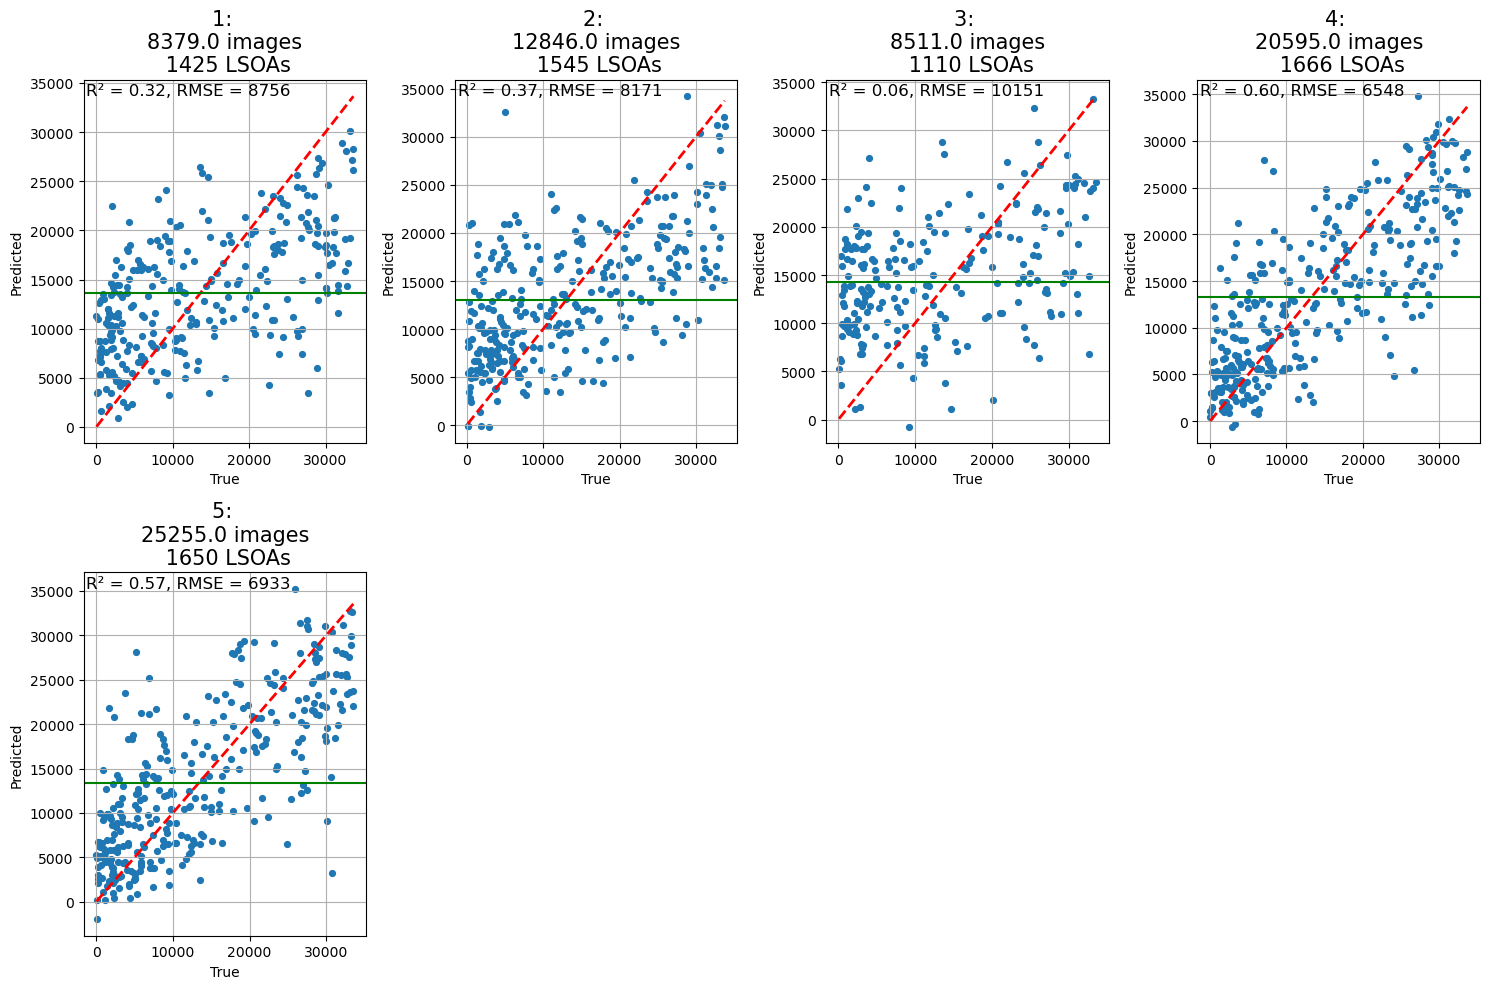

In [25]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(15, 10))
axs = axs.flatten()

results_per_cluster = {}

for i, cluster_num in enumerate(range(1, k + 1)):

    # Clone the best model for each cluster (avoid contamination between clusters)
    model = clone(best_model)

    emb_col = f'{cluster_num}_{statistic}'
    count_col = f'count_{cluster_num}'

    one_image_type = summary_df_with_imd[["LSOA21CD", emb_col, count_col, var_to_predict]].copy()
    num_in_class = one_image_type[count_col].sum()

    # Drop LSOAs where this cluster has no images (embedding is NaN scalar)
    has_embedding = one_image_type[emb_col].apply(lambda x: not (isinstance(x, float) and np.isnan(x)))
    one_image_type = one_image_type[has_embedding].sort_values("LSOA21CD").reset_index(drop=True)
    num_lsoas = len(one_image_type)
    print(f"Cluster {cluster_num}: {num_lsoas} LSOAs, {num_in_class:.0f} images")

    # Build feature matrix from embeddings
    X = np.stack(one_image_type[emb_col].values)
    y = one_image_type[var_to_predict].values

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_imd_model(
        y_test, y_pred, cluster_num, num_in_class, num_lsoas,
        plot=False, plot_collectively=True, ax=axs[i])
    axs[i].axhline(y=one_image_type[var_to_predict].mean(), color='green', linestyle='-')

    results_per_cluster[cluster_num] = metrics

# Hide unused subplot axes
for j in range(i + 1, len(axs)):
    axs[j].axis("off")

fig.tight_layout()

### Results per cluster

In [26]:
pd.DataFrame(results_per_cluster)

,1,2,3,4,5
RMSE,8756.364542,8170.783316,10150.888828,6547.695167,6932.849342
NRMSE,0.823838,0.795459,0.967088,0.633087,0.659311
MAE,7187.564941,6573.263672,8636.492188,5042.647949,5397.032715
R2,0.321291,0.367246,0.064740,0.599200,0.565308
Spearman_rank_corr,0.562759,0.587458,0.351244,0.771536,0.739033


### LaTeX table for paper
Export the per-cluster results as a LaTeX table, with metrics rounded for readability.

In [27]:
# Build a clean DataFrame for the LaTeX table
results_df = pd.DataFrame(results_per_cluster).T
results_df.index.name = "Cluster"

# Format for display: round RMSE/MAE to integers, others to 3 decimal places
format_dict = {
    'RMSE': '{:.0f}',
    'NRMSE': '{:.3f}',
    'MAE': '{:.0f}',
    'R2': '{:.3f}',
    'Spearman_rank_corr': '{:.3f}',
}

# Rename columns for the paper
rename_map = {
    'RMSE': 'RMSE',
    'NRMSE': 'NRMSE',
    'MAE': 'MAE',
    'R2': r'$R^2$',
    'Spearman_rank_corr': r'Spearman $\rho$',
}
latex_df = results_df.rename(columns=rename_map)

# Generate LaTeX
latex_str = latex_df.to_latex(
    float_format="%.3f",
    formatters={
        'RMSE': lambda x: f'{x:.0f}',
        'NRMSE': lambda x: f'{x:.3f}',
        'MAE': lambda x: f'{x:.0f}',
        r'$R^2$': lambda x: f'{x:.3f}',
        r'Spearman $\rho$': lambda x: f'{x:.3f}',
    },
    caption="Per-cluster XGBoost model performance predicting IMD rank from street-view embeddings.",
    label="tab:per_cluster_results",
    column_format="lccccc",
    escape=False,
)

print(latex_str)

\begin{table}
\caption{Per-cluster XGBoost model performance predicting IMD rank from street-view embeddings.}
\label{tab:per_cluster_results}
\begin{tabular}{lccccc}
\toprule
 & RMSE & NRMSE & MAE & $R^2$ & Spearman $\rho$ \\
Cluster &  &  &  &  &  \\
\midrule
1 & 8756 & 0.824 & 7188 & 0.321 & 0.563 \\
2 & 8171 & 0.795 & 6573 & 0.367 & 0.587 \\
3 & 10151 & 0.967 & 8636 & 0.065 & 0.351 \\
4 & 6548 & 0.633 & 5043 & 0.599 & 0.772 \\
5 & 6933 & 0.659 & 5397 & 0.565 & 0.739 \\
\bottomrule
\end{tabular}
\end{table}

